# IT585 Advanced Machine Learning — Lab 7
## Bayesian Inference and Conjugate Priors
| | |
|---|---|
| **Name** | Het Monpara |
| **Roll No** | 202511016 |

---
## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, norm
import time, tracemalloc

np.random.seed(42)
print('All libraries loaded.')

All libraries loaded.


---
# Part 1 — Beta-Binomial Conjugacy (Click-Through Rates)

## 1. The Math

**Goal:** Estimate the true CTR $\theta$ from click / no-click observations.

| | Formula |
|---|---|
| Prior | $\theta \sim \text{Beta}(\alpha_0,\, \beta_0)$ |
| Likelihood | $k \mid \theta \sim \text{Binomial}(N,\, \theta)$ |
| **Posterior** | $\theta \mid k \sim \text{Beta}(\alpha_0 + k,\; \beta_0 + N - k)$ |
| Posterior Mean | $\hat{\theta} = \dfrac{\alpha_0 + k}{\alpha_0 + \beta_0 + N}$ |

> **Key idea:** Just add clicks to $\alpha$, non-clicks to $\beta$. No integration needed.

## 2. Simulation Setup

In [2]:
theta_true = 0.25
N_total    = 500
steps      = [1, 10, 50, 100, 500]
theta_grid = np.linspace(0.001, 0.999, 500)

obs = np.random.binomial(1, theta_true, N_total)   # 1 = click, 0 = no-click

print(f'Total observations : {N_total}')
print(f'Total clicks       : {obs.sum()}')
print(f'Observed CTR       : {obs.mean():.4f}  (true = {theta_true})')

Total observations : 500
Total clicks       : 131
Observed CTR       : 0.2620  (true = 0.25)


## 3. Three Priors + Posterior Update Function

In [3]:
priors = [
    (1,  1,  'Uniform  Beta(1,1)'),
    (10, 1,  'Strong Wrong  Beta(10,1)'),
    (2,  6,  'Weak Correct  Beta(2,6)'),
]

def beta_posterior(a0, b0, data):
    k = int(data.sum())
    return a0 + k, b0 + (len(data) - k)

print(f'Posterior means at N=500  (true theta = {theta_true}):')
print('-' * 52)
for a0, b0, lbl in priors:
    ap, bp = beta_posterior(a0, b0, obs)
    pm = ap / (ap + bp)
    print(f'  {lbl:<30}  ->  {pm:.4f}')

Posterior means at N=500  (true theta = 0.25):
----------------------------------------------------
  Uniform  Beta(1,1)              ->  0.2629
  Strong Wrong  Beta(10,1)        ->  0.2759
  Weak Correct  Beta(2,6)         ->  0.2618


## 4. Sequential Update Plot — Prior / Likelihood / Posterior

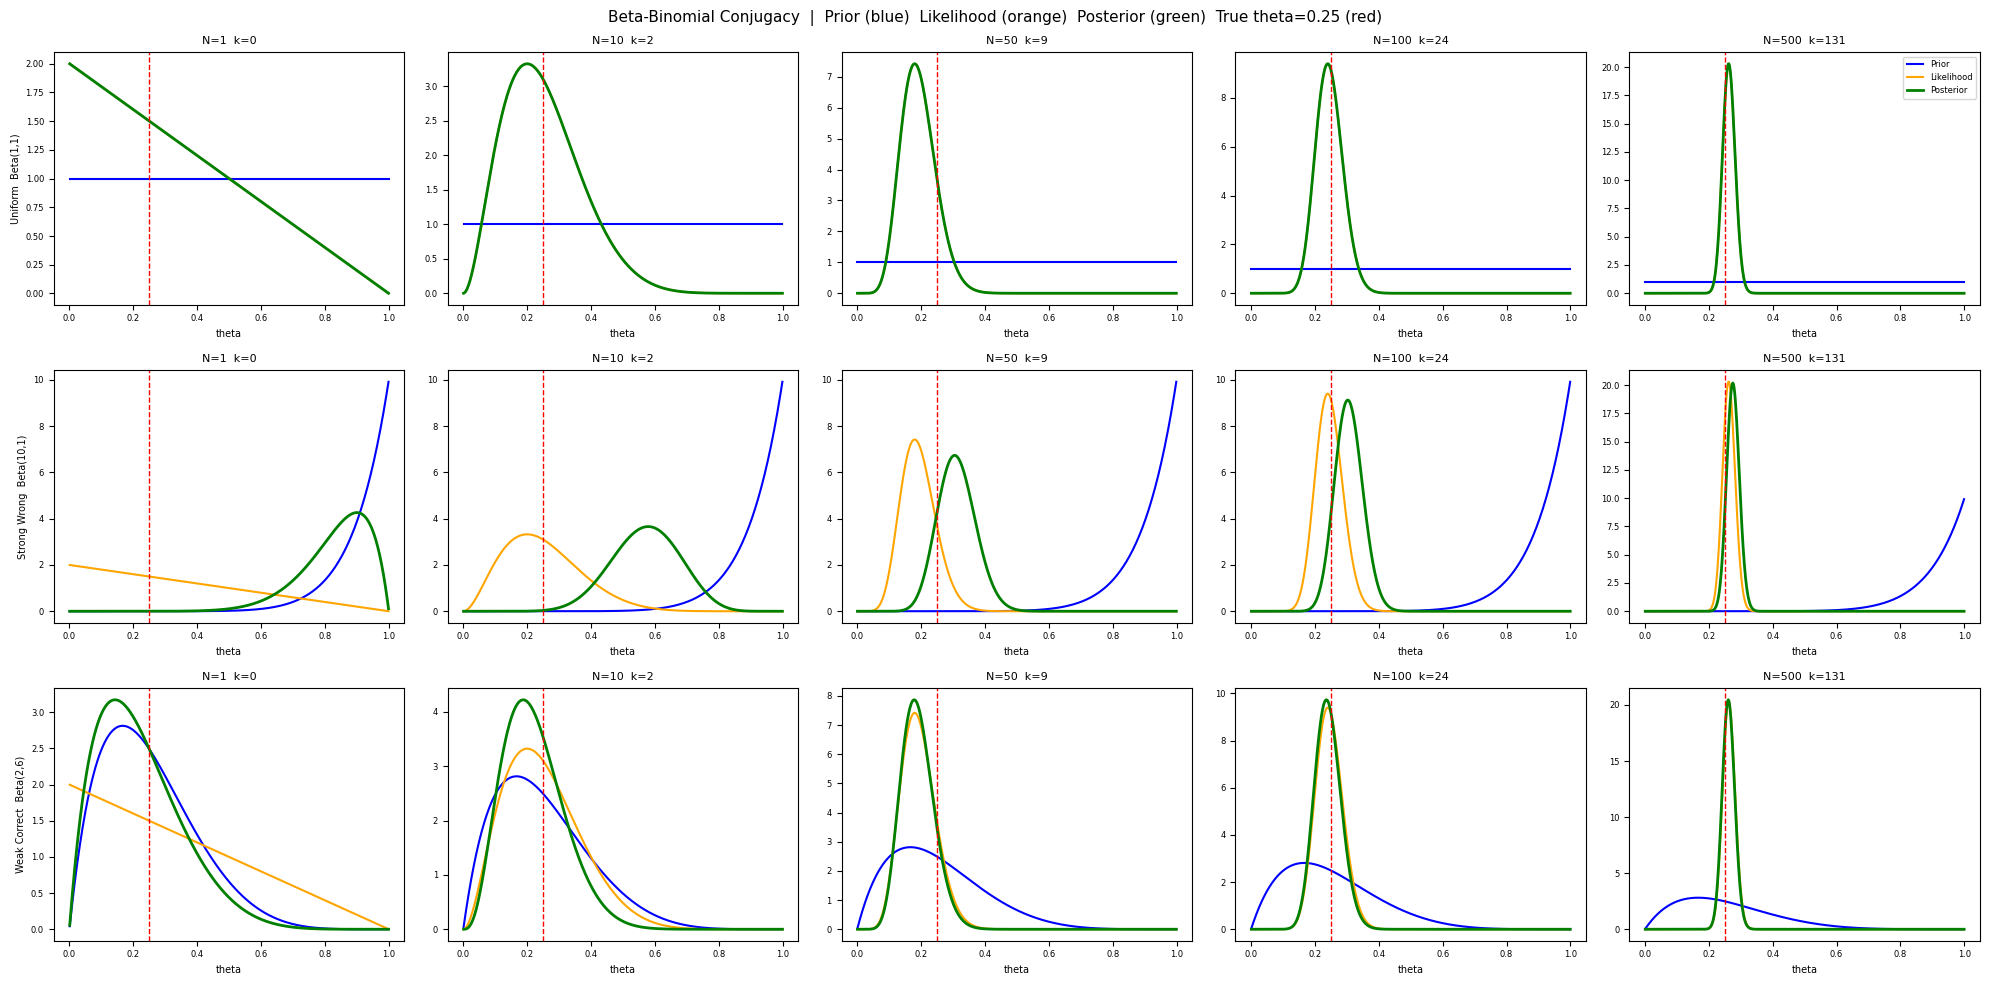

Part 1 plot done.


In [4]:
fig, axes = plt.subplots(3, 5, figsize=(20, 10))
fig.suptitle(
    'Beta-Binomial Conjugacy  |  Prior (blue)  Likelihood (orange)  Posterior (green)  True theta=0.25 (red)',
    fontsize=11
)

for row, (a0, b0, lbl) in enumerate(priors):
    for col, N in enumerate(steps):
        ax   = axes[row][col]
        data = obs[:N]
        k    = int(data.sum())

        # Prior
        prior_pdf = beta.pdf(theta_grid, a0, b0)

        # Normalised likelihood
        lik  = theta_grid**k * (1 - theta_grid)**(N - k)
        lik /= lik.sum() * (theta_grid[1] - theta_grid[0])

        # Posterior
        ap, bp   = beta_posterior(a0, b0, data)
        post_pdf = beta.pdf(theta_grid, ap, bp)

        ax.plot(theta_grid, prior_pdf, 'b',      lw=1.5, label='Prior')
        ax.plot(theta_grid, lik,       'orange', lw=1.5, label='Likelihood')
        ax.plot(theta_grid, post_pdf,  'g',      lw=2.0, label='Posterior')
        ax.axvline(theta_true, color='red', lw=1, ls='--')
        ax.set_title(f'N={N}  k={k}', fontsize=8)
        ax.set_xlabel('theta', fontsize=7)
        ax.tick_params(labelsize=6)
        if col == 0:
            ax.set_ylabel(lbl, fontsize=7)
        if row == 0 and col == 4:
            ax.legend(fontsize=6)

plt.tight_layout()
plt.show()
print('Part 1 plot done.')

### Observations — Part 1
- **All three priors converge** to the true CTR (0.25) as N increases to 500.
- **Beta(10,1)** (strong wrong prior, prior mean ≈ 0.91) requires the most data to correct.
- **Beta(2,6)** (weak correct, prior mean ≈ 0.25) converges fastest — already close to truth.
- **Beta(1,1)** (uniform) starts flat and is purely driven by the data.

---
# Part 2 — Gaussian-Gaussian Conjugacy (Sensor Data)

## 1. The Math

**Goal:** Estimate unknown temperature $\mu$ from noisy sensor readings ($\sigma^2 = 5.0$ known).

| | Formula |
|---|---|
| Prior | $\mu \sim \mathcal{N}(\mu_0,\, \sigma_0^2)$ |
| Likelihood | $x_i \sim \mathcal{N}(\mu,\, \sigma^2)$ |
| **Posterior variance** | $\sigma_N^2 = \left(\dfrac{1}{\sigma_0^2} + \dfrac{N}{\sigma^2}\right)^{-1}$ |
| **Posterior mean** | $\mu_N = \sigma_N^2 \left(\dfrac{\mu_0}{\sigma_0^2} + \dfrac{N\bar{x}}{\sigma^2}\right)$ |

> For large N: $\sigma_N^2 \approx \sigma^2/N$ so uncertainty shrinks at rate $O(1/N)$.

## 2. Generate 100 Data Points from N(22.5, 5.0)

In [5]:
mu_true  = 22.5
sigma2   = 5.0
mu0      = 20.0
sigma0_2 = 10.0
N_data   = 100

data2 = np.random.normal(mu_true, np.sqrt(sigma2), N_data)

print(f'True mean    : {mu_true}')
print(f'Sample mean  : {data2.mean():.4f}')
print(f'Sample std   : {data2.std():.4f}  (true sigma = {np.sqrt(sigma2):.4f})')

True mean    : 22.5
Sample mean  : 22.4657
Sample std   : 2.4156  (true sigma = 2.2361)


## 3. Implement Sequential Bayesian Update

In [6]:
def gauss_posterior(mu0, s0_2, data, s2):
    """Closed-form Gaussian posterior (known variance)."""
    n    = len(data)
    xbar = data.mean()
    sN_2 = 1.0 / (1.0/s0_2 + n/s2)
    mu_N = sN_2 * (mu0/s0_2 + n*xbar/s2)
    return mu_N, sN_2

# Collect posterior after every single observation
ns, post_means, post_vars = [], [], []
for n in range(1, N_data + 1):
    m, v = gauss_posterior(mu0, sigma0_2, data2[:n], sigma2)
    ns.append(n); post_means.append(m); post_vars.append(v)

print(f'  N =   1 :  mean = {post_means[0]:.4f},  var = {post_vars[0]:.4f}')
print(f'  N =  10 :  mean = {post_means[9]:.4f},  var = {post_vars[9]:.4f}')
print(f'  N =  50 :  mean = {post_means[49]:.4f},  var = {post_vars[49]:.4f}')
print(f'  N = 100 :  mean = {post_means[-1]:.4f},  var = {post_vars[-1]:.4f}')

  N =   1 :  mean = 22.1761,  var = 3.3333
  N =  10 :  mean = 23.1064,  var = 0.4762
  N =  50 :  mean = 22.8219,  var = 0.0990
  N = 100 :  mean = 22.4534,  var = 0.0498


## 4. Plots — Posterior Sharpening + Variance vs N

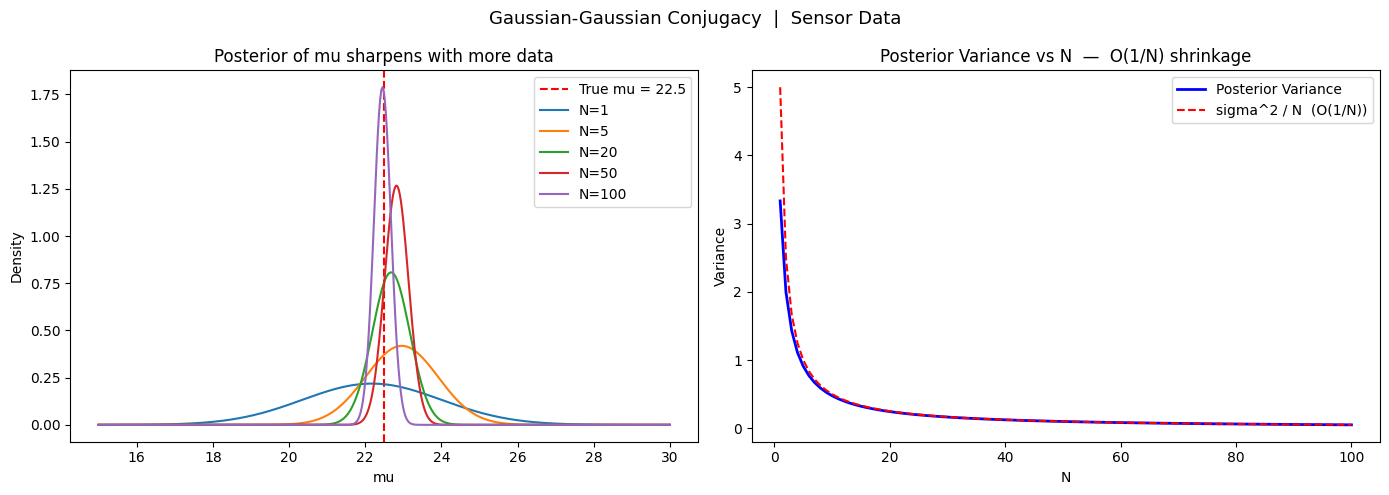

Part 2 plot done.


In [7]:
mu_grid    = np.linspace(15, 30, 500)
plot_steps = [1, 5, 20, 50, 100]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gaussian-Gaussian Conjugacy  |  Sensor Data', fontsize=13)

# Left: posterior distribution sharpening with more data
ax1.axvline(mu_true, color='red', lw=1.5, ls='--', label=f'True mu = {mu_true}')
for n in plot_steps:
    m, v = gauss_posterior(mu0, sigma0_2, data2[:n], sigma2)
    ax1.plot(mu_grid, norm.pdf(mu_grid, m, np.sqrt(v)), label=f'N={n}')
ax1.set_title('Posterior of mu sharpens with more data')
ax1.set_xlabel('mu'); ax1.set_ylabel('Density'); ax1.legend()

# Right: posterior variance vs N — should closely track sigma^2 / N
ax2.plot(ns, post_vars,                     'b',   lw=2,   label='Posterior Variance')
ax2.plot(ns, sigma2 / np.array(ns), 'r--', lw=1.5, label='sigma^2 / N  (O(1/N))')
ax2.set_title('Posterior Variance vs N  —  O(1/N) shrinkage')
ax2.set_xlabel('N'); ax2.set_ylabel('Variance'); ax2.legend()

plt.tight_layout()
plt.show()
print('Part 2 plot done.')

### Observations — Part 2
- Posterior mean moves from **20.0 (prior) toward 22.5 (true)** as N grows.
- Distribution becomes **narrower (more confident)** with each new reading.
- Posterior variance closely tracks $\sigma^2/N$, confirming the $O(1/N)$ shrinkage rate.

---
# Part 3 — Why Conjugacy? (Bimodal Prior + Grid Approximation)

## 1. The Idea

Replace the Gaussian prior with a **bimodal prior** — not conjugate, no closed form.
Use **Grid Approximation** (1000 discrete $\mu$ values):

$$p(\mu \mid \mathbf{x}) \propto p(\mu) \cdot p(\mathbf{x} \mid \mu)
\qquad \text{where} \qquad
\log p(\mathbf{x} \mid \mu) \propto -\frac{N(\bar{x}-\mu)^2}{2\sigma^2}$$

> **Bimodal prior:** $p(\mu) = 0.5\,\mathcal{N}(15,1) + 0.5\,\mathcal{N}(28,1)$ — both peaks are wrong (true $\mu = 22.5$).

## 2. Setup — Bimodal Prior on 1000-Point Grid

In [8]:
N_grid   = 1000
mu_grid3 = np.linspace(10, 35, N_grid)
dx       = mu_grid3[1] - mu_grid3[0]

bimodal_prior  = 0.5 * norm.pdf(mu_grid3, 15, 1) + 0.5 * norm.pdf(mu_grid3, 28, 1)
bimodal_prior /= bimodal_prior.sum() * dx    # normalise

data3 = np.random.normal(mu_true, np.sqrt(sigma2), N_grid)

print(f'Grid range  : [{mu_grid3[0]:.1f}, {mu_grid3[-1]:.1f}]  with {N_grid} points')
print(f'Prior peaks : near mu=15 and mu=28  (both wrong!)')
print(f'Data mean   : {data3.mean():.4f}  (true mu = {mu_true})')

Grid range  : [10.0, 35.0]  with 1000 points
Prior peaks : near mu=15 and mu=28  (both wrong!)
Data mean   : 22.6423  (true mu = 22.5)


## 3. Grid Approximation Function

In [9]:
def grid_posterior(prior, data, s2, grid):
    """Grid approximation: prior x likelihood, then normalise."""
    n       = len(data)
    xbar    = data.mean()
    log_lik = -n * (grid - xbar)**2 / (2 * s2)
    log_lik -= log_lik.max()                        # numerical stability
    post    = prior * np.exp(log_lik)
    post   /= post.sum() * (grid[1] - grid[0])
    return post

# Quick check: where does posterior peak at full N=1000?
post_full = grid_posterior(bimodal_prior, data3, sigma2, mu_grid3)
print(f'Posterior mode at N=1000 : mu = {mu_grid3[np.argmax(post_full)]:.4f}  (true = {mu_true})')

Posterior mode at N=1000 : mu = 22.6627  (true = 22.5)


## 4. Plot — Posterior Evolution Across N Values

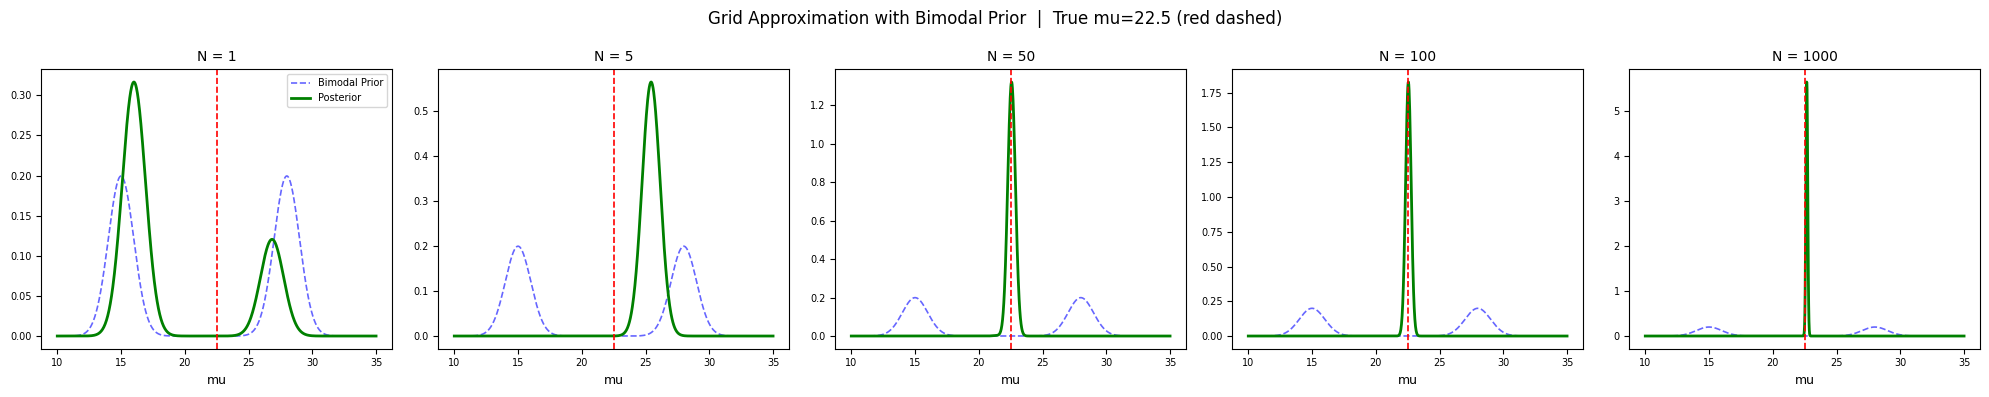

Part 3 plot done.


In [10]:
plot_steps3 = [1, 5, 50, 100, 1000]

fig, axes3 = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Grid Approximation with Bimodal Prior  |  True mu=22.5 (red dashed)', fontsize=12)

for ax, n in zip(axes3, plot_steps3):
    post = grid_posterior(bimodal_prior, data3[:n], sigma2, mu_grid3)
    ax.plot(mu_grid3, bimodal_prior, 'b--', lw=1.2, alpha=0.6, label='Bimodal Prior')
    ax.plot(mu_grid3, post,          'g',   lw=2,              label='Posterior')
    ax.axvline(mu_true, color='red', lw=1.2, ls='--')
    ax.set_title(f'N = {n}', fontsize=10)
    ax.set_xlabel('mu', fontsize=9)
    ax.tick_params(labelsize=7)
    if n == 1:
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()
print('Part 3 plot done.')

## 5. Benchmark: Grid Approximation vs Closed-Form (N = 1000)

In [11]:
def benchmark(fn):
    tracemalloc.start()
    t0 = time.perf_counter()
    fn()
    t_ms = (time.perf_counter() - t0) * 1000
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return t_ms, peak / 1024

t_g, m_g = benchmark(lambda: grid_posterior(bimodal_prior, data3, sigma2, mu_grid3))
t_c, m_c = benchmark(lambda: gauss_posterior(mu0, sigma0_2, data3, sigma2))

print(f'{"Method":<28} {"Time (ms)":>12} {"Memory (KB)":>14}')
print('-' * 58)
print(f'{"Grid Approximation":<28} {t_g:>12.4f} {m_g:>14.2f}')
print(f'{"Conjugate (Closed-Form)":<28} {t_c:>12.4f} {m_c:>14.2f}')
print('-' * 58)
print(f'Grid is ~{t_g/max(t_c,1e-9):.0f}x slower  and  ~{m_g/max(m_c,0.01):.0f}x more memory')

Method                          Time (ms)    Memory (KB)
----------------------------------------------------------
Grid Approximation                 3.1773          23.86
Conjugate (Closed-Form)            0.2400           0.77
----------------------------------------------------------
Grid is ~13x slower  and  ~31x more memory


### Observations — Part 3
- At **N=1**: posterior ≈ bimodal prior (data has almost no power yet).
- As N grows: **likelihood overrides the wrong modes** → posterior shifts toward true $\mu = 22.5$.
- By **N=1000**: posterior is tightly concentrated at the correct value.
- Grid approximation is **significantly slower and memory-heavy** vs closed-form — scales poorly in higher dimensions (curse of dimensionality).
- This is **why conjugate priors are preferred** when they exist: exact, instant, and memory-efficient.

---
# Viva Prep Answers

---
### Q1. If the prior in Part 1 is Beta(0, 0), what happens? Is it a valid probability distribution?

- **Beta(0,0) is an improper prior** — it does not integrate to 1, so it is **not a valid probability distribution**.
- It places infinite weight at $\theta = 0$ and $\theta = 1$ (the boundary extremes).
- The resulting posterior $\text{Beta}(k,\, N-k)$ can still be proper **only if** $k > 0$ and $N-k > 0$ (at least one click and one non-click). Otherwise, the posterior is also improper and the model fails.

---
### Q2. What happens to the posterior mean if $\sigma_0^2 \to \infty$?

- A very large $\sigma_0^2$ means the prior is **completely flat / uninformative** — we have no prior knowledge.
- The prior precision $1/\sigma_0^2 \to 0$, so the prior term vanishes from the posterior update:
$$\mu_N = \sigma_N^2\!\left(\underbrace{\frac{\mu_0}{\sigma_0^2}}_{\to\,0} + \frac{N\bar{x}}{\sigma^2}\right) \xrightarrow{\;\sigma_0^2\to\infty\;} \bar{x}$$
- **Result: posterior mean equals the sample mean (MLE).** Data entirely controls the estimate; prior has zero influence.

---
### Q3. How do conjugate priors act as pseudo-observations / virtual data counts?

**Beta-Binomial:**
- $\alpha_0$ acts like $\alpha_0 - 1$ **imaginary prior clicks** already seen.
- $\beta_0$ acts like $\beta_0 - 1$ **imaginary prior non-clicks** already seen.
- Example: `Beta(10,1)` is as if you had seen 9 clicks and 0 non-clicks before any real data.

**Gaussian-Gaussian:**
- A small $\sigma_0^2$ (tight prior) = strong belief = behaves like having seen **many past observations** near $\mu_0$.
- A large $\sigma_0^2$ (flat prior) = no past data at all.

> **Intuition:** The prior is pre-loaded data. Real observations just add to the same counter — Bayesian updating feels like appending rows to a dataset.